# Feature Engineering - Dự đoán trả hàng ở cấp Order

## Mục tiêu
- Xây dựng dữ liệu với grain chính thức: **1 dòng = 1 `order_id` = 1 label**.
- Target lấy từ `orders.order_status`; `returns.csv` không được sử dụng trong FE.
- Phase 3 tạo candidate feature rộng để nghiên cứu.
- Phase 4 loại leakage tập trung trước relevance, correlation và wrapper.
- Chỉ feature có sẵn tại thời điểm đặt hàng mới được bàn giao cho Modeling.

## Quy trình
- **Phase 0:** Setup & Config
- **Phase 1:** Load & Audit dữ liệu
- **Phase 2:** Clean, tạo label và khóa temporal cutoff
- **Phase 3:** Tạo candidate feature ở cấp order
- **Phase 4:** Leakage Gate, Screening & Selection
- **Phase 5:** Format & Preprocessing
- **Phase 6:** Materialize Train/Validation/Test
- **Phase 7:** Readiness Check & Report


---
## Phase 0 - Setup & Config

In [1]:
# Import thư viện và cấu hình
from pathlib import Path
import hashlib
import json
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse, stats
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET_COLUMN = "returned_label"
PRIMARY_SELECTION_METRIC = "pr_auc"


In [2]:
# Khai báo đường dẫn output
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "Data"
REPORT_DIR = PROJECT_ROOT / "report_12_6_2026"
FE_OUTPUT_DIR = REPORT_DIR / "fe_outputs"
FE_TABLE_DIR = FE_OUTPUT_DIR / "tables"
FE_FIGURE_DIR = FE_OUTPUT_DIR / "figures"
FE_REPORT_DIR = FE_OUTPUT_DIR / "reports"

for directory in [FE_TABLE_DIR, FE_FIGURE_DIR, FE_REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FE_OUTPUT_DIR:", FE_OUTPUT_DIR)

PROJECT_ROOT: B:\DA_VSF\customer_churn_PL
FE_OUTPUT_DIR: B:\DA_VSF\customer_churn_PL\report_12_6_2026\fe_outputs


In [3]:
# Feature map theo EDA và vai trò trong pipeline
HIGH_FEATURES = [
    "is_cod",
    "payment_method",
    "mean_product_return_rate",
    "max_product_return_rate",
    "high_risk_product_count",
]

MEDIUM_FEATURES = [
    "customer_tenure_days",
    "tenure_group",
    "age_group",
    "gender",
    "device_type",
    "order_source",
    "payment_value",
    "log_payment_value",
    "payment_value_quantile_bucket",
    "total_quantity",
    "unique_product_count",
    "discount_ratio",
    "is_discounted",
]

LOW_FEATURES = [
    "payment_device_interaction",
    "order_month",
    "order_quarter",
    "order_day_of_week",
    "is_weekend",
    "is_q4",
]

feature_policy = pd.DataFrame(
    [
        *[{"feature": f, "priority": "high"} for f in HIGH_FEATURES],
        *[{"feature": f, "priority": "medium"} for f in MEDIUM_FEATURES],
        *[{"feature": f, "priority": "low_experimental"} for f in LOW_FEATURES],
    ]
)
feature_policy.to_csv(FE_TABLE_DIR / "phase0_feature_policy.csv", index=False)
display(feature_policy)

,feature,priority
0,is_cod,high
1,payment_method,high
2,mean_product_return_rate,high
3,max_product_return_rate,high
4,high_risk_product_count,high
5,customer_tenure_days,medium
6,tenure_group,medium
7,age_group,medium
8,gender,medium
9,device_type,medium


---
## Phase 1 - Load & Audit Dữ Liệu

In [4]:
# Load các bảng được phép sử dụng từ FE trở đi
orders = pd.read_csv(DATA_DIR / "orders.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
customers = pd.read_csv(DATA_DIR / "customers.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")

tables = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "payments": payments,
}

table_overview = pd.DataFrame(
    [{"table": name, "n_rows": len(df), "n_cols": df.shape[1]} for name, df in tables.items()]
)
table_overview.to_csv(FE_TABLE_DIR / "phase1_table_overview.csv", index=False)
display(table_overview)


,table,n_rows,n_cols
0,orders,646945,8
1,order_items,714669,7
2,customers,121930,7
3,products,2412,8
4,payments,646945,4


In [5]:
# Audit missing, dtype và duplicate key
schema_rows = []
for table_name, table in tables.items():
    for column in table.columns:
        schema_rows.append(
            {
                "table": table_name,
                "column": column,
                "dtype": str(table[column].dtype),
                "missing_count": int(table[column].isna().sum()),
                "missing_rate": float(table[column].isna().mean()),
            }
        )

schema_audit = pd.DataFrame(schema_rows)
duplicate_audit = pd.DataFrame(
    [
        {"table": "orders", "key": "order_id", "duplicate_rows": int(orders.duplicated("order_id").sum())},
        {"table": "payments", "key": "order_id", "duplicate_rows": int(payments.duplicated("order_id").sum())},
        {"table": "customers", "key": "customer_id", "duplicate_rows": int(customers.duplicated("customer_id").sum())},
        {"table": "products", "key": "product_id", "duplicate_rows": int(products.duplicated("product_id").sum())},
        {
            "table": "order_items",
            "key": "order_id + product_id",
            "duplicate_rows": int(order_items.duplicated(["order_id", "product_id"], keep=False).sum()),
        },
    ]
)

schema_audit.to_csv(FE_TABLE_DIR / "phase1_schema_audit.csv", index=False)
duplicate_audit.to_csv(FE_TABLE_DIR / "phase1_duplicate_key_audit.csv", index=False)
display(schema_audit)
display(duplicate_audit)

,table,column,dtype,missing_count,missing_rate
0,orders,order_id,int64,0,0.000000
1,orders,order_date,str,0,0.000000
2,orders,customer_id,int64,0,0.000000
3,orders,zip,int64,0,0.000000
4,orders,order_status,str,0,0.000000
5,orders,payment_method,str,0,0.000000
6,orders,device_type,str,0,0.000000
7,orders,order_source,str,0,0.000000
8,order_items,order_id,int64,0,0.000000
9,order_items,product_id,int64,0,0.000000


,table,key,duplicate_rows
0,orders,order_id,0
1,payments,order_id,0
2,customers,customer_id,0
3,products,product_id,0
4,order_items,order_id + product_id,32


---
## Phase 2 - Clean, Label & Lock Temporal Cutoffs

Target thuộc cấp order và chỉ lấy từ `orders.order_status`.
`returns.csv` không được load, join, audit hoặc dùng làm feature từ FE trở đi.


In [6]:
# Chuẩn hóa kiểu ngày cần thiết cho FE
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")

date_audit = pd.DataFrame(
    [
        {"table": "orders", "column": "order_date", "parse_errors": int(orders["order_date"].isna().sum())},
        {"table": "customers", "column": "signup_date", "parse_errors": int(customers["signup_date"].isna().sum())},
    ]
)
date_audit.to_csv(FE_TABLE_DIR / "phase2_date_audit.csv", index=False)
display(date_audit)


,table,column,parse_errors
0,orders,order_date,0
1,customers,signup_date,0


In [7]:
# Loại promo khỏi FE và aggregate các line item cùng order-product
items_work = order_items.drop(columns=["promo_id", "promo_id_2"], errors="ignore").copy()
items_work["line_gross_value"] = items_work["quantity"] * items_work["unit_price"]

duplicate_item_rows = items_work.loc[
    items_work.duplicated(["order_id", "product_id"], keep=False)
].copy()
duplicate_key_detail = (
    duplicate_item_rows.groupby(["order_id", "product_id"], as_index=False)
    .size()
    .rename(columns={"size": "line_count"})
)
distinct_line_counts = (
    duplicate_item_rows.drop_duplicates()
    .groupby(["order_id", "product_id"], as_index=False)
    .size()
    .rename(columns={"size": "distinct_line_count"})
)
duplicate_key_detail = duplicate_key_detail.merge(
    distinct_line_counts,
    on=["order_id", "product_id"],
    how="left",
)
duplicate_key_detail["decision"] = np.where(
    duplicate_key_detail["line_count"].eq(duplicate_key_detail["distinct_line_count"]),
    "aggregate_valid_multiple_lines",
    "review_exact_duplicate",
)

before_quantity = float(items_work["quantity"].sum())
before_discount = float(items_work["discount_amount"].sum())
before_gross = float(items_work["line_gross_value"].sum())

order_items_clean = (
    items_work
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(
        quantity=("quantity", "sum"),
        discount_amount=("discount_amount", "sum"),
        line_gross_value=("line_gross_value", "sum"),
    )
)
order_items_clean["unit_price_weighted"] = np.where(
    order_items_clean["quantity"].gt(0),
    order_items_clean["line_gross_value"] / order_items_clean["quantity"],
    np.nan,
)

order_payment_reconciliation = (
    order_items_clean.groupby("order_id", as_index=False)
    .agg(
        total_gross_value=("line_gross_value", "sum"),
        total_discount_amount=("discount_amount", "sum"),
    )
    .assign(net_order_value=lambda x: x["total_gross_value"] - x["total_discount_amount"])
    .merge(payments[["order_id", "payment_value"]], on="order_id", how="left")
)
order_payment_reconciliation["payment_difference"] = (
    order_payment_reconciliation["net_order_value"]
    - order_payment_reconciliation["payment_value"]
)
payment_mismatch_count = int(
    order_payment_reconciliation["payment_difference"].abs().gt(1e-6).sum()
)
payment_reconciliation_audit = pd.DataFrame(
    [
        {
            "orders_checked": len(order_payment_reconciliation),
            "payment_mismatch_count": payment_mismatch_count,
            "max_absolute_difference": float(
                order_payment_reconciliation["payment_difference"].abs().max()
            ),
            "tolerance": 1e-6,
        }
    ]
)

item_aggregation_audit = pd.DataFrame(
    [
        {
            "metric": "rows",
            "before": len(order_items),
            "after": len(order_items_clean),
            "difference": len(order_items_clean) - len(order_items),
        },
        {
            "metric": "total_quantity",
            "before": before_quantity,
            "after": float(order_items_clean["quantity"].sum()),
            "difference": float(order_items_clean["quantity"].sum()) - before_quantity,
        },
        {
            "metric": "total_discount",
            "before": before_discount,
            "after": float(order_items_clean["discount_amount"].sum()),
            "difference": float(order_items_clean["discount_amount"].sum()) - before_discount,
        },
        {
            "metric": "total_gross_value",
            "before": before_gross,
            "after": float(order_items_clean["line_gross_value"].sum()),
            "difference": float(order_items_clean["line_gross_value"].sum()) - before_gross,
        },
    ]
)
item_aggregation_audit.to_csv(FE_TABLE_DIR / "phase2_item_aggregation_audit.csv", index=False)
duplicate_key_detail.to_csv(FE_TABLE_DIR / "phase2_duplicate_item_decisions.csv", index=False)
payment_reconciliation_audit.to_csv(FE_TABLE_DIR / "phase2_order_payment_reconciliation.csv", index=False)
display(duplicate_key_detail)
display(item_aggregation_audit)
print("Payment mismatches after aggregation:", payment_mismatch_count)

,order_id,product_id,line_count,distinct_line_count,decision
0,14280,976,2,2,aggregate_valid_multiple_lines
1,113379,786,2,2,aggregate_valid_multiple_lines
2,215525,1859,2,2,aggregate_valid_multiple_lines
3,216740,791,2,2,aggregate_valid_multiple_lines
4,243342,777,2,2,aggregate_valid_multiple_lines
5,265263,2394,2,2,aggregate_valid_multiple_lines
6,397622,2045,2,2,aggregate_valid_multiple_lines
7,398385,2016,2,2,aggregate_valid_multiple_lines
8,428208,2090,2,2,aggregate_valid_multiple_lines
9,530051,2219,2,2,aggregate_valid_multiple_lines


,metric,before,after,difference
0,rows,7.146690e+05,7.146530e+05,-16.0
1,total_quantity,3.213143e+06,3.213143e+06,0.0
2,total_discount,7.496073e+08,7.496073e+08,0.0
3,total_gross_value,1.643048e+10,1.643048e+10,0.0


Payment mismatches after aggregation: 0


In [8]:
# Tạo label order-level từ orders.order_status
label_map = {"delivered": 0, "returned": 1}
orders_fe = orders.copy()
orders_fe["returned_label"] = orders_fe["order_status"].map(label_map)

label_audit = (
    orders_fe.groupby(["order_status", "returned_label"], dropna=False)
    .size()
    .reset_index(name="order_count")
)

valid_orders = (
    orders_fe.dropna(subset=["returned_label"])
    .copy()
    .assign(returned_label=lambda x: x["returned_label"].astype(int))
)

payment_order_ids = set(payments["order_id"])
label_source_audit = pd.DataFrame(
    [
        {
            "check": "label_source_is_orders_order_status",
            "passed": True,
            "detail": "returned=1; delivered=0; other statuses excluded",
        },
        {
            "check": "valid_orders_missing_payment",
            "passed": int((~valid_orders["order_id"].isin(payment_order_ids)).sum()) == 0,
            "detail": int((~valid_orders["order_id"].isin(payment_order_ids)).sum()),
        },
        {
            "check": "one_row_per_labeled_order",
            "passed": valid_orders["order_id"].is_unique,
            "detail": int(valid_orders["order_id"].duplicated().sum()),
        },
    ]
)

label_audit.to_csv(FE_TABLE_DIR / "phase2_label_audit.csv", index=False)
label_source_audit.to_csv(FE_TABLE_DIR / "phase2_label_source_audit.csv", index=False)
display(label_audit)
display(label_source_audit)
print("Valid order rows:", len(valid_orders))


,order_status,returned_label,order_count
0,cancelled,NaN,59462
1,created,NaN,7275
2,delivered,0.0,516716
3,paid,NaN,13577
4,returned,1.0,36142
5,shipped,NaN,13773


,check,passed,detail
0,label_source_is_orders_order_status,True,returned=1; delivered=0; other statuses excluded
1,valid_orders_missing_payment,True,0
2,one_row_per_labeled_order,True,0


Valid order rows: 552858


In [9]:
# Khóa cutoff 70/15/15 trước selection; file split chỉ được materialize ở Phase 6
order_split_frame = valid_orders[["order_id", "order_date"]].sort_values(["order_date", "order_id"])
train_position = int(len(order_split_frame) * 0.70)
valid_position = int(len(order_split_frame) * 0.85)
TRAIN_CUT_DATE = order_split_frame.iloc[train_position]["order_date"]
VALID_CUT_DATE = order_split_frame.iloc[valid_position]["order_date"]

def assign_split(order_date):
    if order_date < TRAIN_CUT_DATE:
        return "train"
    if order_date < VALID_CUT_DATE:
        return "validation"
    return "test"

valid_orders["data_split"] = valid_orders["order_date"].map(assign_split)
split_contract = (
    valid_orders.groupby("data_split")
    .agg(
        n_orders=("order_id", "nunique"),
        start_date=("order_date", "min"),
        end_date=("order_date", "max"),
        return_rate=("returned_label", "mean"),
    )
    .reset_index()
)
split_contract["role_before_phase6"] = "internal_outer_holdout_mask"
split_contract.to_csv(FE_TABLE_DIR / "phase2_temporal_cutoff_contract.csv", index=False)
display(split_contract)


,data_split,n_orders,start_date,end_date,return_rate,role_before_phase6
0,test,83045,2020-03-28,2022-12-31,0.067036,internal_outer_holdout_mask
1,train,386907,2012-07-04,2018-04-27,0.065370,internal_outer_holdout_mask
2,validation,82906,2018-04-28,2020-03-27,0.063723,internal_outer_holdout_mask


---
## Phase 3 - Feature Engineering Ở Cấp Order

In [10]:
# 3.1 - Base classification table: một dòng duy nhất cho mỗi order
base_orders = valid_orders[
    [
        "order_id",
        "order_date",
        "customer_id",
        "payment_method",
        "device_type",
        "order_source",
        "returned_label",
        "data_split",
    ]
].copy()

base_audit = pd.DataFrame(
    [
        {
            "n_rows": len(base_orders),
            "n_unique_orders": base_orders["order_id"].nunique(),
            "duplicate_order_ids": int(base_orders.duplicated("order_id").sum()),
            "return_rate": base_orders["returned_label"].mean(),
        }
    ]
)
base_audit.to_csv(FE_TABLE_DIR / "phase3_1_base_order_audit.csv", index=False)
display(base_audit)

,n_rows,n_unique_orders,duplicate_order_ids,return_rate
0,552858,552858,0,0.065373


In [11]:
# 3.2 - GS1 Customer Profile
customer_orders = base_orders[["order_id", "customer_id", "order_date"]].merge(
    customers[["customer_id", "signup_date", "gender", "age_group"]],
    on="customer_id",
    how="left",
)

first_order_date = (
    orders_fe.groupby("customer_id", as_index=False)["order_date"]
    .min()
    .rename(columns={"order_date": "first_order_date"})
)
customer_orders = customer_orders.merge(first_order_date, on="customer_id", how="left")
customer_orders["customer_tenure_days"] = (
    customer_orders["order_date"] - customer_orders["first_order_date"]
).dt.days
customer_orders["tenure_group"] = pd.cut(
    customer_orders["customer_tenure_days"],
    bins=[-1, 29, 179, 364, np.inf],
    labels=["new_lt_30d", "30_179d", "180_364d", "loyal_365d_plus"],
)

customer_date_audit = pd.DataFrame(
    [
        {
            "check": "order_date_before_signup_date",
            "issue_count": int(customer_orders["order_date"].lt(customer_orders["signup_date"]).sum()),
            "decision": "use_first_observed_order_for_tenure",
        },
        {
            "check": "negative_observed_tenure",
            "issue_count": int(customer_orders["customer_tenure_days"].lt(0).sum()),
            "decision": "must_be_zero",
        },
    ]
)
customer_date_audit.to_csv(FE_TABLE_DIR / "phase3_2_customer_date_audit.csv", index=False)

customer_features = customer_orders[
    ["order_id", "customer_tenure_days", "tenure_group", "age_group", "gender"]
].copy()
display(customer_date_audit)
display(customer_features.head())

,check,issue_count,decision
0,order_date_before_signup_date,409392,use_first_observed_order_for_tenure
1,negative_observed_tenure,0,must_be_zero


,order_id,customer_tenure_days,tenure_group,age_group,gender
0,1,0,new_lt_30d,35-44,Female
1,2,0,new_lt_30d,18-24,Female
2,3,0,new_lt_30d,35-44,Female
3,4,0,new_lt_30d,45-54,Male
4,6,0,new_lt_30d,18-24,Male


In [12]:
# 3.3 - GS2 Product descriptors: aggregate về order và tạo multi-hot
item_product = order_items_clean.merge(
    products[["product_id", "category", "segment", "size", "color"]],
    on="product_id",
    how="left",
)

order_item_summary = (
    item_product.groupby("order_id", as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        unique_product_count=("product_id", "nunique"),
        total_discount_amount=("discount_amount", "sum"),
        total_gross_value=("line_gross_value", "sum"),
    )
)
order_item_summary["discount_ratio"] = np.where(
    order_item_summary["total_gross_value"].gt(0),
    order_item_summary["total_discount_amount"] / order_item_summary["total_gross_value"],
    0.0,
)
order_item_summary["discount_ratio"] = order_item_summary["discount_ratio"].clip(0, 1)
order_item_summary["is_discounted"] = order_item_summary["total_discount_amount"].gt(0).astype(int)

def make_multihot(frame, column, prefix):
    multihot = pd.crosstab(frame["order_id"], frame[column])
    multihot = multihot.gt(0).astype("int8")
    multihot.columns = [f"{prefix}_{str(value)}" for value in multihot.columns]
    return multihot.reset_index()

category_multihot = make_multihot(item_product, "category", "category")
segment_multihot = make_multihot(item_product, "segment", "segment")
size_multihot = make_multihot(item_product, "size", "size")
color_multihot = make_multihot(item_product, "color", "color")

product_descriptor_features = (
    order_item_summary
    .merge(category_multihot, on="order_id", how="left")
    .merge(segment_multihot, on="order_id", how="left")
    .merge(size_multihot, on="order_id", how="left")
    .merge(color_multihot, on="order_id", how="left")
)
display(product_descriptor_features.head())

,order_id,total_quantity,unique_product_count,total_discount_amount,total_gross_value,discount_ratio,is_discounted,category_Casual,category_GenZ,category_Outdoor,category_Streetwear,segment_Activewear,segment_All-weather,segment_Balanced,segment_Everyday,segment_Performance,segment_Premium,segment_Standard,segment_Trendy,size_L,size_M,size_S,size_XL,color_black,color_blue,color_green,color_orange,color_pink,color_purple,color_red,color_silver,color_white,color_yellow
0,1,7,1,0.0,7967.54,0.0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0
1,2,7,1,0.0,71163.75,0.0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
2,3,3,1,0.0,33660.99,0.0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
3,4,5,1,0.0,53196.25,0.0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,6,1,1,0.0,1597.84,0.0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [13]:
# 3.3b - Candidate target-history features (research only; leakage gate evaluates them)
product_order_history = (
    item_product[["order_id", "product_id"]]
    .drop_duplicates()
    .merge(base_orders[["order_id", "order_date", "returned_label"]], on="order_id", how="inner")
)

product_daily = (
    product_order_history.groupby(["product_id", "order_date"], as_index=False)
    .agg(
        date_return_sum=("returned_label", "sum"),
        date_order_count=("returned_label", "count"),
    )
    .sort_values(["product_id", "order_date"])
)
product_daily["past_return_sum"] = (
    product_daily.groupby("product_id")["date_return_sum"].cumsum()
    - product_daily["date_return_sum"]
)
product_daily["past_order_count"] = (
    product_daily.groupby("product_id")["date_order_count"].cumsum()
    - product_daily["date_order_count"]
)

global_daily = (
    base_orders.groupby("order_date", as_index=False)
    .agg(date_return_sum=("returned_label", "sum"), date_order_count=("returned_label", "count"))
    .sort_values("order_date")
)
global_daily["prior_global_return_sum"] = global_daily["date_return_sum"].cumsum() - global_daily["date_return_sum"]
global_daily["prior_global_order_count"] = global_daily["date_order_count"].cumsum() - global_daily["date_order_count"]
global_daily["prior_global_return_rate"] = np.where(
    global_daily["prior_global_order_count"].gt(0),
    global_daily["prior_global_return_sum"] / global_daily["prior_global_order_count"],
    0.0,
)

product_daily = product_daily.merge(
    global_daily[["order_date", "prior_global_return_rate"]],
    on="order_date",
    how="left",
)
product_daily["product_return_rate_before_order"] = np.where(
    product_daily["past_order_count"].gt(0),
    product_daily["past_return_sum"] / product_daily["past_order_count"],
    product_daily["prior_global_return_rate"],
)
product_daily["is_high_risk_product"] = (
    product_daily["past_order_count"].ge(30)
    & product_daily["product_return_rate_before_order"].ge(0.10)
).astype(int)

product_history_order = (
    product_order_history[["order_id", "product_id", "order_date"]]
    .merge(
        product_daily[
            [
                "product_id",
                "order_date",
                "product_return_rate_before_order",
                "is_high_risk_product",
                "past_order_count",
            ]
        ],
        on=["product_id", "order_date"],
        how="left",
    )
    .groupby("order_id", as_index=False)
    .agg(
        mean_product_return_rate=("product_return_rate_before_order", "mean"),
        max_product_return_rate=("product_return_rate_before_order", "max"),
        high_risk_product_count=("is_high_risk_product", "sum"),
        min_product_history_count=("past_order_count", "min"),
    )
)

history_audit = pd.DataFrame(
    [
        {
            "feature_group": "product_target_history",
            "uses_target_outcome": True,
            "outcome_observed_timestamp_available": False,
            "modeling_eligible": False,
            "decision_stage": "Phase 4 leakage gate",
            "min_product_history_count": product_history_order["min_product_history_count"].min(),
        }
    ]
)
history_audit.to_csv(FE_TABLE_DIR / "phase3_product_target_history_candidate_audit.csv", index=False)
display(history_audit)


,feature_group,uses_target_outcome,outcome_observed_timestamp_available,modeling_eligible,decision_stage,min_product_history_count
0,product_target_history,True,False,False,Phase 4 leakage gate,0


In [14]:
# 3.4 - GS3 Payment & Device
payment_features = base_orders[
    ["order_id", "payment_method", "device_type", "order_source"]
].merge(
    payments[["order_id", "payment_value"]],
    on="order_id",
    how="left",
)
payment_features["is_cod"] = payment_features["payment_method"].eq("cod").astype(int)
payment_features["payment_device_interaction"] = (
    payment_features["payment_method"].fillna("Unknown").astype(str)
    + "_"
    + payment_features["device_type"].fillna("Unknown").astype(str)
)
payment_features["log_payment_value"] = np.log1p(payment_features["payment_value"].clip(lower=0))
display(payment_features.head())

,order_id,payment_method,device_type,order_source,payment_value,is_cod,payment_device_interaction,log_payment_value
0,1,credit_card,desktop,paid_search,7967.54,0,credit_card_desktop,8.983257
1,2,cod,mobile,paid_search,71163.75,1,cod_mobile,11.172753
2,3,credit_card,desktop,direct,33660.99,0,credit_card_desktop,10.424125
3,4,credit_card,desktop,referral,53196.25,0,credit_card_desktop,10.881762
4,6,paypal,mobile,email_campaign,1597.84,0,paypal_mobile,7.377034


In [15]:
# 3.5 - Payment value bucket fit bằng train בלבד
train_order_ids = set(base_orders.loc[base_orders["data_split"].eq("train"), "order_id"])
train_payment = payment_features.loc[
    payment_features["order_id"].isin(train_order_ids),
    "payment_value",
].dropna()

payment_quantile_edges = np.unique(
    train_payment.quantile([0, 0.25, 0.50, 0.75, 1.0]).to_numpy()
)
payment_quantile_edges[0] = -np.inf
payment_quantile_edges[-1] = np.inf

payment_features["payment_value_quantile_bucket"] = pd.cut(
    payment_features["payment_value"],
    bins=payment_quantile_edges,
    labels=[f"Q{i + 1}" for i in range(len(payment_quantile_edges) - 1)],
    include_lowest=True,
)

pd.DataFrame({"quantile_edge": payment_quantile_edges}).to_csv(
    FE_TABLE_DIR / "phase3_payment_quantile_edges_train_only.csv",
    index=False,
)
print("Train-only payment edges:", payment_quantile_edges)

Train-only payment edges: [     -inf  7147.74  16035.42  31804.145       inf]


In [16]:
# 3.6 - GS5 Time & Seasonality
time_features = base_orders[["order_id", "order_date"]].copy()
time_features["order_month"] = time_features["order_date"].dt.month
time_features["order_quarter"] = time_features["order_date"].dt.quarter
time_features["order_day_of_week"] = time_features["order_date"].dt.dayofweek
time_features["is_weekend"] = time_features["order_day_of_week"].isin([5, 6]).astype(int)
time_features["is_q4"] = time_features["order_quarter"].eq(4).astype(int)
display(time_features.head())

,order_id,order_date,order_month,order_quarter,order_day_of_week,is_weekend,is_q4
0,1,2012-07-04,7,3,2,0,0
1,2,2012-07-04,7,3,2,0,0
2,3,2012-07-04,7,3,2,0,0
3,4,2012-07-04,7,3,2,0,0
4,6,2012-07-06,7,3,4,0,0


In [17]:
# 3.7 - Merge feature table order-level
phase3_features = (
    base_orders
    .merge(customer_features, on="order_id", how="left")
    .merge(product_descriptor_features, on="order_id", how="left")
    .merge(product_history_order.drop(columns=["min_product_history_count"]), on="order_id", how="left")
    .merge(payment_features, on=["order_id", "payment_method", "device_type", "order_source"], how="left")
    .merge(time_features, on=["order_id", "order_date"], how="left")
)

multihot_columns = [
    column
    for column in phase3_features.columns
    if column.startswith(("category_", "segment_", "size_", "color_"))
]
phase3_features[multihot_columns] = phase3_features[multihot_columns].fillna(0).astype("int8")

phase3_check = pd.DataFrame(
    [
        {"check": "row_count_equals_valid_orders", "passed": len(phase3_features) == len(valid_orders), "detail": len(phase3_features)},
        {"check": "order_id_is_unique", "passed": phase3_features["order_id"].is_unique, "detail": int(phase3_features["order_id"].duplicated().sum())},
        {"check": "target_binary", "passed": set(phase3_features["returned_label"].unique()) <= {0, 1}, "detail": sorted(phase3_features["returned_label"].unique())},
        {"check": "expected_order_count", "passed": len(phase3_features) == 552858, "detail": len(phase3_features)},
        {"check": "promo_columns_removed", "passed": not {"promo_id", "promo_id_2"} & set(phase3_features.columns), "detail": "promo_id,promo_id_2"},
    ]
)

phase3_features.to_csv(FE_TABLE_DIR / "phase3_features_order_grain.csv", index=False)
phase3_features.to_csv(FE_TABLE_DIR / "phase3_features_all.csv", index=False)
phase3_check.to_csv(FE_TABLE_DIR / "phase3_feature_check.csv", index=False)
display(phase3_check)
print("Phase 3 shape:", phase3_features.shape)

,check,passed,detail
0,row_count_equals_valid_orders,True,552858
1,order_id_is_unique,True,0
2,target_binary,True,"[0, 1]"
3,expected_order_count,True,552858
4,promo_columns_removed,True,"promo_id,promo_id_2"


Phase 3 shape: (552858, 57)


## Kết luận Phase 3

- Grain chính thức là một dòng cho mỗi `order_id`.
- `phase3_features` là bảng candidate nội bộ, chưa phải bảng an toàn cho Modeling.
- Product categorical được biểu diễn multi-hot ở cấp order.
- Ba product target-history feature vẫn được tạo để audit, nhưng chưa được phép đi qua leakage gate.
- Target lấy duy nhất từ `orders.order_status`; FE không sử dụng `returns.csv`.
- `payment_value_quantile_bucket` vẫn tồn tại trong candidate table để audit nhưng
  bị loại khỏi Modeling; raw `payment_value` và `log_payment_value` được giữ để
  preprocessing trong từng inner CV fold không phụ thuộc thống kê fit trước fold.


---
## Phase 4 - Leakage Gate, Screening & Selection

Phase 4 chạy hoàn toàn trên outer train. Outer validation và test không được dùng để chọn feature.


In [18]:
# 4.1 - Feature availability catalog và leakage gate tập trung
ID_COLUMNS = ["order_id", "customer_id"]
META_COLUMNS = ["order_date", "data_split"]
POST_OUTCOME_COLUMNS = {
    "order_status",
    "return_date",
    "return_reason",
    "refund_amount",
    "return_quantity",
    "has_return_record",
}
TARGET_DERIVED_FEATURES = {
    "mean_product_return_rate",
    "max_product_return_rate",
    "high_risk_product_count",
}
EXCLUDED_REPRESENTATIONS = {
    "total_discount_amount": "Intermediate monetary total",
    "total_gross_value": "Intermediate monetary total",
    "payment_value_quantile_bucket": (
        "Train-fitted derived representation; raw/log payment value is retained so "
        "preprocessing can be refit inside each temporal CV fold"
    ),
}

def infer_feature_metadata(column):
    if column in ID_COLUMNS:
        return "identifier", "source key", False, True
    if column in META_COLUMNS:
        return "metadata", "pipeline control", False, True
    if column == TARGET_COLUMN:
        return "target", "orders.order_status mapped to 0/1", True, False
    if column in TARGET_DERIVED_FEATURES:
        return (
            "product_target_history",
            "aggregate of historical returned_label by product",
            True,
            False,
        )
    if column in POST_OUTCOME_COLUMNS:
        return "post_outcome", "available only after order outcome", False, False
    if column.startswith(("category_", "segment_", "size_", "color_")):
        return "product_descriptor", "order-item multi-hot aggregation", False, True
    if column in {"customer_tenure_days", "tenure_group", "age_group", "gender"}:
        return "customer", "customer/order information available at order time", False, True
    if column in {
        "payment_method", "device_type", "order_source", "payment_value", "is_cod",
        "payment_device_interaction", "log_payment_value", "payment_value_quantile_bucket",
    }:
        return "payment_order", "payment/order attributes available at order time", False, True
    if column.startswith("order_") or column in {"is_weekend", "is_q4"}:
        return "calendar", "derived from order_date", False, True
    return "order_item", "order/item aggregate available at order time", False, True

availability_rows = []
for column in phase3_features.columns:
    source_group, formula, uses_target, available_at_order_time = infer_feature_metadata(column)
    if column in ID_COLUMNS:
        role, action, reason = "id", "EXCLUDE_ID", "Identifier is retained only for audit"
    elif column in META_COLUMNS:
        role, action, reason = "metadata", "EXCLUDE_METADATA", "Metadata is retained only for temporal control"
    elif column == TARGET_COLUMN:
        role, action, reason = "target", "EXCLUDE_TARGET", "Target is y and cannot be included in X"
    elif column in TARGET_DERIVED_FEATURES:
        role, action, reason = (
            "feature",
            "BAN_LEAKAGE",
            "Historical target outcome availability is not guaranteed at order time",
        )
    elif column in POST_OUTCOME_COLUMNS:
        role, action, reason = "feature", "BAN_LEAKAGE", "Post-outcome information"
    elif column in EXCLUDED_REPRESENTATIONS:
        role, action, reason = (
            "feature",
            "EXCLUDE_REPRESENTATION",
            EXCLUDED_REPRESENTATIONS[column],
        )
    else:
        role, action, reason = "feature", "PASS_LEAKAGE_GATE", "Available at order time"
    availability_rows.append(
        {
            "column": column,
            "role": role,
            "source_group": source_group,
            "formula_or_origin": formula,
            "uses_target": uses_target,
            "available_at_order_time": available_at_order_time,
            "action": action,
            "reason": reason,
        }
    )

feature_availability_catalog = pd.DataFrame(availability_rows)
leakage_gate_df = feature_availability_catalog.loc[
    feature_availability_catalog["role"].eq("feature")
].copy()
candidate_features = leakage_gate_df["column"].tolist()
banned_features = set(
    leakage_gate_df.loc[leakage_gate_df["action"].eq("BAN_LEAKAGE"), "column"]
)
leakage_safe_features = leakage_gate_df.loc[
    leakage_gate_df["action"].eq("PASS_LEAKAGE_GATE"), "column"
].tolist()

feature_availability_catalog.to_csv(
    FE_TABLE_DIR / "phase4_feature_availability_catalog.csv", index=False
)
leakage_gate_df.to_csv(FE_TABLE_DIR / "phase4_leakage_gate.csv", index=False)
display(leakage_gate_df.sort_values(["action", "column"]))

expected_banned = TARGET_DERIVED_FEATURES
if not expected_banned <= banned_features:
    raise RuntimeError("Target-history features did not pass through BAN_LEAKAGE.")


,column,role,source_group,formula_or_origin,uses_target,available_at_order_time,action,reason
46,high_risk_product_count,feature,product_target_history,aggregate of historical returned_label by product,True,False,BAN_LEAKAGE,Historical target outcome availability is not ...
45,max_product_return_rate,feature,product_target_history,aggregate of historical returned_label by product,True,False,BAN_LEAKAGE,Historical target outcome availability is not ...
44,mean_product_return_rate,feature,product_target_history,aggregate of historical returned_label by product,True,False,BAN_LEAKAGE,Historical target outcome availability is not ...
51,payment_value_quantile_bucket,feature,payment_order,payment/order attributes available at order time,False,True,EXCLUDE_REPRESENTATION,Train-fitted derived representation; raw/log p...
14,total_discount_amount,feature,order_item,order/item aggregate available at order time,False,True,EXCLUDE_REPRESENTATION,Intermediate monetary total
15,total_gross_value,feature,order_item,order/item aggregate available at order time,False,True,EXCLUDE_REPRESENTATION,Intermediate monetary total
10,age_group,feature,customer,customer/order information available at order ...,False,True,PASS_LEAKAGE_GATE,Available at order time
18,category_Casual,feature,product_descriptor,order-item multi-hot aggregation,False,True,PASS_LEAKAGE_GATE,Available at order time
19,category_GenZ,feature,product_descriptor,order-item multi-hot aggregation,False,True,PASS_LEAKAGE_GATE,Available at order time
20,category_Outdoor,feature,product_descriptor,order-item multi-hot aggregation,False,True,PASS_LEAKAGE_GATE,Available at order time


In [19]:
# 4.2 - Quality filter chỉ trên leakage-safe features và outer train
outer_train_df = phase3_features.loc[phase3_features["data_split"].eq("train")].copy()

def series_signature(series):
    hashed = pd.util.hash_pandas_object(series, index=False).to_numpy()
    return hashlib.sha256(hashed.tobytes()).hexdigest()

preliminary_quality = {}
for feature in leakage_safe_features:
    series = outer_train_df[feature]
    missing_rate = float(series.isna().mean())
    nunique = int(series.nunique(dropna=True))
    invalid_count = (
        int(np.isinf(pd.to_numeric(series, errors="coerce")).sum())
        if pd.api.types.is_numeric_dtype(series)
        else 0
    )
    if nunique <= 1:
        action, reason = "DROP_QUALITY", "Constant on outer train"
    elif missing_rate > 0.60:
        action, reason = "DROP_QUALITY", "Missing rate above 60% on outer train"
    elif invalid_count > 0:
        action, reason = "DROP_QUALITY", "Infinite numeric values"
    else:
        action, reason = "KEEP", "Passed quality rules"
    preliminary_quality[feature] = {
        "feature": feature,
        "dtype": str(series.dtype),
        "missing_rate": missing_rate,
        "nunique": nunique,
        "invalid_count": invalid_count,
        "signature": series_signature(series),
        "action": action,
        "reason": reason,
        "duplicate_of": "",
    }

signature_owner = {}
for feature in leakage_safe_features:
    row = preliminary_quality[feature]
    if row["action"] != "KEEP":
        continue
    signature = row["signature"]
    owner = signature_owner.get(signature)
    if owner is not None and outer_train_df[feature].equals(outer_train_df[owner]):
        row["action"] = "DROP_QUALITY"
        row["reason"] = "Exact duplicate column on outer train"
        row["duplicate_of"] = owner
    else:
        signature_owner[signature] = feature

quality_df = pd.DataFrame(preliminary_quality.values()).drop(columns=["signature"])
quality_pass_features = quality_df.loc[quality_df["action"].eq("KEEP"), "feature"].tolist()
quality_df.to_csv(FE_TABLE_DIR / "phase4_quality_filter.csv", index=False)
display(quality_df.sort_values(["action", "feature"]))


,feature,dtype,missing_rate,nunique,invalid_count,action,reason,duplicate_of
22,segment_Trendy,int8,0.0,2,0,DROP_QUALITY,Exact duplicate column on outer train,category_GenZ
5,age_group,str,0.0,5,0,KEEP,Passed quality rules,
11,category_Casual,int8,0.0,2,0,KEEP,Passed quality rules,
12,category_GenZ,int8,0.0,2,0,KEEP,Passed quality rules,
13,category_Outdoor,int8,0.0,2,0,KEEP,Passed quality rules,
14,category_Streetwear,int8,0.0,2,0,KEEP,Passed quality rules,
27,color_black,int8,0.0,2,0,KEEP,Passed quality rules,
28,color_blue,int8,0.0,2,0,KEEP,Passed quality rules,
29,color_green,int8,0.0,2,0,KEEP,Passed quality rules,
30,color_orange,int8,0.0,2,0,KEEP,Passed quality rules,


,feature,metric,score,effect_size,p_value,selection_role,data_used
38,payment_device_interaction,cramers_v,0.078531,0.078531,0.000000,ranking_only,outer_train_only
37,is_cod,point_biserial_r,0.078478,0.078478,0.000000,ranking_only,outer_train_only
0,payment_method,cramers_v,0.078426,0.078426,0.000000,ranking_only,outer_train_only
1,device_type,cramers_v,0.003876,0.003876,0.020100,ranking_only,outer_train_only
36,payment_value,point_biserial_r,-0.003853,0.003853,0.016558,ranking_only,outer_train_only
8,unique_product_count,point_biserial_r,0.003607,0.003607,0.024845,ranking_only,outer_train_only
27,color_blue,point_biserial_r,-0.003527,0.003527,0.028234,ranking_only,outer_train_only
17,segment_Balanced,point_biserial_r,-0.003348,0.003348,0.037294,ranking_only,outer_train_only
13,category_Outdoor,point_biserial_r,0.002993,0.002993,0.062658,ranking_only,outer_train_only
15,segment_Activewear,point_biserial_r,0.002939,0.002939,0.067557,ranking_only,outer_train_only


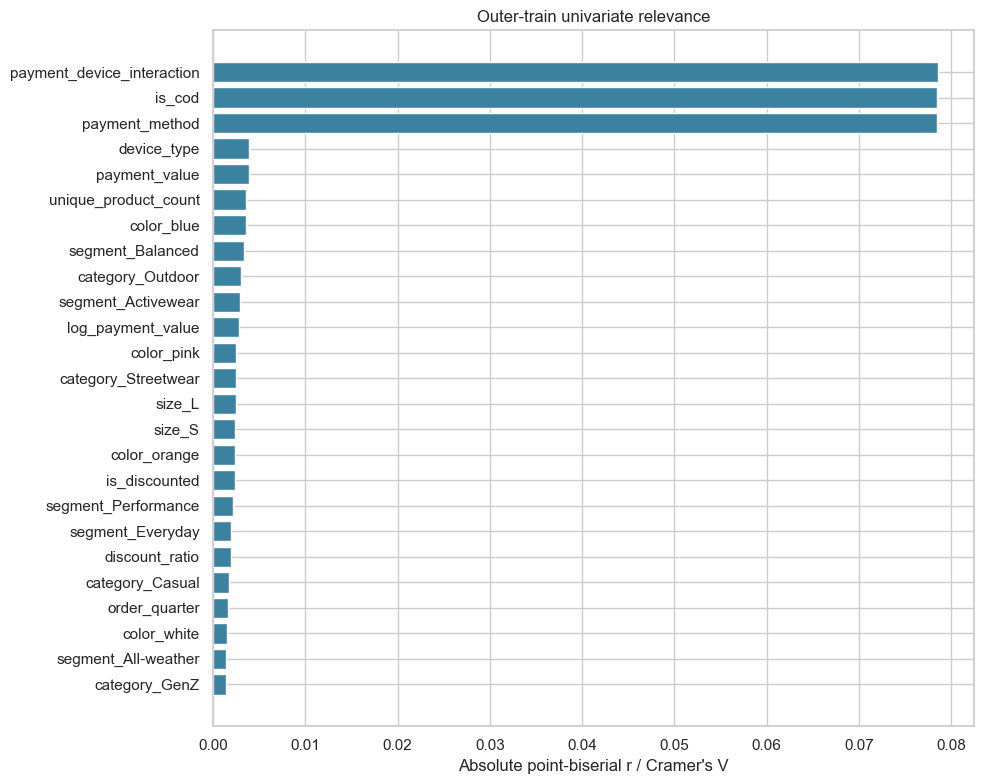

In [20]:
# 4.3 - Relevance ranking chỉ trên outer train
def cramers_v(contingency):
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return 0.0
    chi2 = chi2_contingency(contingency, correction=False)[0]
    n = contingency.to_numpy().sum()
    if n <= 1:
        return 0.0
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denominator = min(k_corr - 1, r_corr - 1)
    return float(np.sqrt(phi2_corr / denominator)) if denominator > 0 else 0.0

relevance_rows = []
for feature in quality_pass_features:
    series = outer_train_df[feature]
    target = outer_train_df[TARGET_COLUMN]
    valid = series.notna() & target.notna()
    if pd.api.types.is_numeric_dtype(series):
        x = pd.to_numeric(series[valid], errors="coerce")
        y = target[valid]
        numeric_valid = x.notna()
        if numeric_valid.sum() > 30 and x[numeric_valid].nunique() > 1:
            score, p_value = stats.pointbiserialr(y.loc[numeric_valid], x.loc[numeric_valid])
        else:
            score, p_value = 0.0, 1.0
        metric = "point_biserial_r"
        effect_size = abs(float(score))
    else:
        contingency = pd.crosstab(series[valid].astype(str), target[valid])
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            _, p_value, _, _ = chi2_contingency(contingency)
            effect_size = cramers_v(contingency)
        else:
            p_value, effect_size = 1.0, 0.0
        score = effect_size
        metric = "cramers_v"
    relevance_rows.append(
        {
            "feature": feature,
            "metric": metric,
            "score": float(score),
            "effect_size": float(effect_size),
            "p_value": float(p_value),
            "selection_role": "ranking_only",
            "data_used": "outer_train_only",
        }
    )

relevance_df = pd.DataFrame(relevance_rows).sort_values("effect_size", ascending=False)
effect_map = relevance_df.set_index("feature")["effect_size"].to_dict()
relevance_df.to_csv(FE_TABLE_DIR / "phase4_relevance_report.csv", index=False)
display(relevance_df.head(25))

fig, ax = plt.subplots(figsize=(10, 8))
plot_df = relevance_df.head(25).sort_values("effect_size")
ax.barh(plot_df["feature"], plot_df["effect_size"], color="#3B82A0")
ax.set_title("Outer-train univariate relevance")
ax.set_xlabel("Absolute point-biserial r / Cramer's V")
plt.tight_layout()
fig.savefig(FE_FIGURE_DIR / "phase4_relevance_outer_train.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
# 4.4 - Redundancy và representation-family audit
feature_family_map = {
    "cod_payment": ["is_cod", "payment_method"],
    "customer_tenure": ["customer_tenure_days", "tenure_group"],
    "payment_value": ["payment_value", "log_payment_value"],
}
family_rows = []
for family, features in feature_family_map.items():
    for feature in features:
        if feature in quality_pass_features:
            family_rows.append(
                {
                    "family": family,
                    "feature": feature,
                    "action": "EVALUATE_IN_WRAPPER",
                    "reason": "Same concept family; no manual drop",
                }
            )
feature_family_df = pd.DataFrame(family_rows)

numeric_candidates = [
    feature for feature in quality_pass_features
    if pd.api.types.is_numeric_dtype(outer_train_df[feature])
]
numeric_corr = outer_train_df[numeric_candidates].corr().abs()
redundancy_rows = []
dropped_redundant = set()
for i, feature_a in enumerate(numeric_candidates):
    if feature_a in dropped_redundant:
        continue
    for feature_b in numeric_candidates[i + 1:]:
        if feature_b in dropped_redundant:
            continue
        association = float(numeric_corr.loc[feature_a, feature_b])
        if association > 0.98:
            kept = max([feature_a, feature_b], key=lambda f: effect_map.get(f, 0.0))
            dropped = feature_b if kept == feature_a else feature_a
            if dropped not in dropped_redundant:
                dropped_redundant.add(dropped)
                redundancy_rows.append(
                    {
                        "feature_a": feature_a,
                        "feature_b": feature_b,
                        "association_type": "absolute_pearson_outer_train",
                        "association_value": association,
                        "kept": kept,
                        "dropped": dropped,
                    }
                )

redundancy_df = pd.DataFrame(redundancy_rows)
screened_features = [
    feature for feature in quality_pass_features
    if feature not in dropped_redundant
]
feature_family_df.to_csv(FE_TABLE_DIR / "phase4_representation_families.csv", index=False)
redundancy_df.to_csv(FE_TABLE_DIR / "phase4_redundancy_pairs.csv", index=False)
display(feature_family_df)
display(redundancy_df)
print("Features after leakage, quality and redundancy:", len(screened_features))


,family,feature,action,reason
0,cod_payment,is_cod,EVALUATE_IN_WRAPPER,Same concept family; no manual drop
1,cod_payment,payment_method,EVALUATE_IN_WRAPPER,Same concept family; no manual drop
2,customer_tenure,customer_tenure_days,EVALUATE_IN_WRAPPER,Same concept family; no manual drop
3,customer_tenure,tenure_group,EVALUATE_IN_WRAPPER,Same concept family; no manual drop
4,payment_value,payment_value,EVALUATE_IN_WRAPPER,Same concept family; no manual drop
5,payment_value,log_payment_value,EVALUATE_IN_WRAPPER,Same concept family; no manual drop


,feature_a,feature_b,association_type,association_value,kept,dropped
0,category_Casual,segment_All-weather,absolute_pearson_outer_train,0.987855,category_Casual,segment_All-weather


Features after leakage, quality and redundancy: 44


In [22]:
# 4.5 - Dual-model wrapper trên 3 inner temporal folds của outer train
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def split_feature_types(feature_columns, reference_df):
    binary = [
        feature for feature in feature_columns
        if pd.api.types.is_numeric_dtype(reference_df[feature])
        and set(reference_df[feature].dropna().unique()) <= {0, 1}
    ]
    numeric = [
        feature for feature in feature_columns
        if pd.api.types.is_numeric_dtype(reference_df[feature]) and feature not in binary
    ]
    categorical = [
        feature for feature in feature_columns
        if feature not in numeric and feature not in binary
    ]
    return numeric, categorical, binary

def make_preprocessor(feature_columns, reference_df):
    numeric, categorical, binary = split_feature_types(feature_columns, reference_df)
    transformers = []
    if numeric:
        transformers.append(
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric,
            )
        )
    if categorical:
        transformers.append(
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical,
            )
        )
    if binary:
        transformers.append(("binary", SimpleImputer(strategy="most_frequent"), binary))
    if "payment_value" in feature_columns:
        transformers.append(
            (
                "payment_quantile",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        (
                            "quantile_bins",
                            KBinsDiscretizer(
                                n_bins=4,
                                encode="onehot",
                                strategy="quantile",
                                subsample=None,
                            ),
                        ),
                    ]
                ),
                ["payment_value"],
            )
        )
    return ColumnTransformer(transformers, remainder="drop")

def build_wrapper_model(model_name, feature_columns, reference_df, scale_pos_weight=1.0):
    if model_name == "logistic":
        classifier = LogisticRegression(
            solver="liblinear",
            class_weight="balanced",
            max_iter=250,
            random_state=RANDOM_STATE,
        )
    elif model_name == "lightgbm":
        classifier = lgb.LGBMClassifier(
            n_estimators=150,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
    else:
        raise ValueError(f"Unknown wrapper model: {model_name}")
    return Pipeline(
        [
            ("preprocessor", make_preprocessor(feature_columns, reference_df)),
            ("classifier", classifier),
        ]
    )

selection_pool = outer_train_df.sort_values(["order_date", "order_id"]).copy()
unique_dates = np.array(sorted(selection_pool["order_date"].dropna().unique()))
fold_boundaries = [(0.40, 0.60), (0.60, 0.80), (0.80, 1.00)]
temporal_folds = []
for fold_number, (train_end_fraction, valid_end_fraction) in enumerate(fold_boundaries, start=1):
    train_end_date = pd.Timestamp(
        unique_dates[min(int(len(unique_dates) * train_end_fraction), len(unique_dates) - 1)]
    )
    valid_end_date = pd.Timestamp(
        unique_dates[min(int(len(unique_dates) * valid_end_fraction), len(unique_dates) - 1)]
    )
    train_mask = selection_pool["order_date"] < train_end_date
    if fold_number == len(fold_boundaries):
        valid_mask = selection_pool["order_date"].ge(train_end_date) & selection_pool["order_date"].le(valid_end_date)
    else:
        valid_mask = selection_pool["order_date"].ge(train_end_date) & selection_pool["order_date"].lt(valid_end_date)
    temporal_folds.append((fold_number, train_mask, valid_mask, train_end_date, valid_end_date))

baseline_features = ["is_cod"]
wrapper_candidates = [feature for feature in screened_features if feature not in baseline_features]
wrapper_rows = []
for model_name in ["logistic", "lightgbm"]:
    baseline_scores = {}
    for fold_number, train_mask, valid_mask, train_end_date, valid_end_date in temporal_folds:
        fold_train = selection_pool.loc[train_mask]
        fold_valid = selection_pool.loc[valid_mask]
        positives = fold_train[TARGET_COLUMN].sum()
        fold_weight = (len(fold_train) - positives) / positives
        baseline_model = build_wrapper_model(
            model_name, baseline_features, fold_train, scale_pos_weight=fold_weight
        )
        baseline_model.fit(fold_train[baseline_features], fold_train[TARGET_COLUMN])
        baseline_probability = baseline_model.predict_proba(fold_valid[baseline_features])[:, 1]
        baseline_scores[fold_number] = {
            "pr_auc": average_precision_score(fold_valid[TARGET_COLUMN], baseline_probability),
            "roc_auc": roc_auc_score(fold_valid[TARGET_COLUMN], baseline_probability),
        }
    for feature in wrapper_candidates:
        feature_set = baseline_features + [feature]
        for fold_number, train_mask, valid_mask, train_end_date, valid_end_date in temporal_folds:
            fold_train = selection_pool.loc[train_mask]
            fold_valid = selection_pool.loc[valid_mask]
            positives = fold_train[TARGET_COLUMN].sum()
            fold_weight = (len(fold_train) - positives) / positives
            model = build_wrapper_model(
                model_name, feature_set, fold_train, scale_pos_weight=fold_weight
            )
            model.fit(fold_train[feature_set], fold_train[TARGET_COLUMN])
            probability = model.predict_proba(fold_valid[feature_set])[:, 1]
            pr_auc = average_precision_score(fold_valid[TARGET_COLUMN], probability)
            roc_auc = roc_auc_score(fold_valid[TARGET_COLUMN], probability)
            wrapper_rows.append(
                {
                    "model": model_name,
                    "feature": feature,
                    "fold": fold_number,
                    "train_end_date": train_end_date,
                    "validation_end_date": valid_end_date,
                    "pr_auc": pr_auc,
                    "baseline_pr_auc": baseline_scores[fold_number]["pr_auc"],
                    "delta_pr_auc": pr_auc - baseline_scores[fold_number]["pr_auc"],
                    "roc_auc": roc_auc,
                    "baseline_roc_auc": baseline_scores[fold_number]["roc_auc"],
                    "delta_roc_auc": roc_auc - baseline_scores[fold_number]["roc_auc"],
                }
            )

wrapper_long_df = pd.DataFrame(wrapper_rows)
wrapper_summary_df = (
    wrapper_long_df.groupby(["model", "feature"], as_index=False)
    .agg(
        mean_delta_pr_auc=("delta_pr_auc", "mean"),
        negative_pr_folds=("delta_pr_auc", lambda x: int((x < 0).sum())),
        min_delta_pr_auc=("delta_pr_auc", "min"),
        max_delta_pr_auc=("delta_pr_auc", "max"),
        mean_delta_roc_auc=("delta_roc_auc", "mean"),
        negative_roc_folds=("delta_roc_auc", lambda x: int((x < 0).sum())),
    )
)
wrapper_summary_df["model_consistent_harm"] = (
    wrapper_summary_df["mean_delta_pr_auc"].le(-0.001)
    & wrapper_summary_df["negative_pr_folds"].eq(3)
)

consensus_df = (
    wrapper_summary_df.pivot(
        index="feature", columns="model", values="model_consistent_harm"
    )
    .fillna(False)
    .reset_index()
)
for required_model in ["logistic", "lightgbm"]:
    if required_model not in consensus_df:
        consensus_df[required_model] = False
consensus_df["consistent_harm_consensus"] = (
    consensus_df["logistic"].astype(bool) & consensus_df["lightgbm"].astype(bool)
)
consensus_df["decision"] = np.where(
    consensus_df["consistent_harm_consensus"],
    "DROP_CONSISTENT_HARM",
    "KEEP_OR_WATCH",
)

wrapper_long_df.to_csv(FE_TABLE_DIR / "phase4_wrapper_temporal_folds.csv", index=False)
wrapper_summary_df.loc[wrapper_summary_df["model"].eq("logistic")].to_csv(
    FE_TABLE_DIR / "phase4_wrapper_logistic.csv", index=False
)
wrapper_summary_df.loc[wrapper_summary_df["model"].eq("lightgbm")].to_csv(
    FE_TABLE_DIR / "phase4_wrapper_lightgbm.csv", index=False
)
wrapper_summary_df.to_csv(FE_TABLE_DIR / "phase4_wrapper_summary.csv", index=False)
consensus_df.to_csv(FE_TABLE_DIR / "phase4_wrapper_consensus.csv", index=False)
display(consensus_df.sort_values(["decision", "feature"]))


C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\MSII\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


model,feature,lightgbm,logistic,consistent_harm_consensus,decision
0,age_group,False,False,False,KEEP_OR_WATCH
1,category_Casual,False,False,False,KEEP_OR_WATCH
2,category_GenZ,False,False,False,KEEP_OR_WATCH
3,category_Outdoor,False,False,False,KEEP_OR_WATCH
4,category_Streetwear,False,False,False,KEEP_OR_WATCH
5,color_black,False,False,False,KEEP_OR_WATCH
6,color_blue,False,False,False,KEEP_OR_WATCH
7,color_green,False,False,False,KEEP_OR_WATCH
8,color_orange,False,False,False,KEEP_OR_WATCH
9,color_pink,False,False,False,KEEP_OR_WATCH


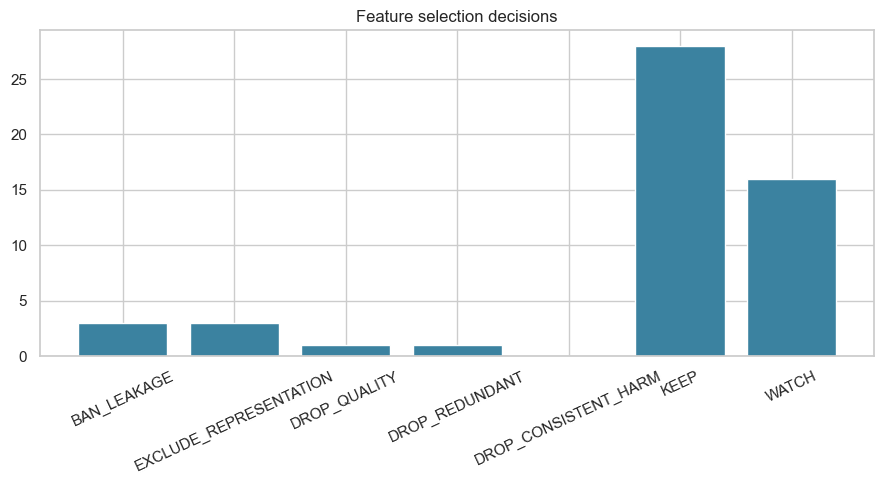

Banned leakage: ['high_risk_product_count', 'max_product_return_rate', 'mean_product_return_rate']
Core: ['is_cod', 'payment_method']
V1 feature count: 28
Experimental feature count: 16


In [23]:
# 4.6 - Chốt Core, V1 và Experimental sau toàn bộ selection funnel
consistent_harm_features = set(
    consensus_df.loc[
        consensus_df["consistent_harm_consensus"], "feature"
    ]
)
category_features = [c for c in screened_features if c.startswith("category_")]
segment_features = [c for c in screened_features if c.startswith("segment_")]
size_features = [c for c in screened_features if c.startswith("size_")]
color_features = [c for c in screened_features if c.startswith("color_")]

experimental_candidates = {
    feature for feature in screened_features
    if feature in LOW_FEATURES
    or feature in color_features
    or feature == "payment_device_interaction"
}
v1_candidate_features = [
    feature for feature in screened_features
    if feature not in experimental_candidates
]

wrapper_metric_map = (
    wrapper_summary_df.set_index(["model", "feature"]).to_dict("index")
)
stable_positive_features = {
    feature for feature in wrapper_candidates
    if all(
        wrapper_metric_map.get((model_name, feature), {}).get("mean_delta_pr_auc", -np.inf) > 0
        for model_name in ["logistic", "lightgbm"]
    )
}

core_seed_safe = [
    feature for feature in HIGH_FEATURES
    if feature in screened_features
    and feature not in banned_features
    and feature not in consistent_harm_features
]
feature_cols_core = list(dict.fromkeys(
    ["is_cod"]
    + [feature for feature in core_seed_safe if feature in stable_positive_features]
))
feature_cols_v1 = [
    feature for feature in v1_candidate_features
    if feature not in consistent_harm_features
]
feature_cols_experimental = [
    feature for feature in experimental_candidates
    if feature not in consistent_harm_features
]

all_modeling_features = set(feature_cols_core + feature_cols_v1 + feature_cols_experimental)
if banned_features & all_modeling_features:
    raise RuntimeError("Leakage-gated features entered a modeling feature set.")
if len(feature_cols_v1) <= 1:
    raise RuntimeError("Feature selection returned one or fewer V1 features.")

quality_map = quality_df.set_index("feature").to_dict("index")
consensus_map = consensus_df.set_index("feature").to_dict("index")
selection_rows = []
for feature in candidate_features:
    gate_record = leakage_gate_df.loc[leakage_gate_df["column"].eq(feature)].iloc[0]
    if gate_record["action"] == "BAN_LEAKAGE":
        final_group, decision, reason = "banned", "BAN_LEAKAGE", gate_record["reason"]
    elif gate_record["action"] != "PASS_LEAKAGE_GATE":
        final_group, decision, reason = "excluded", gate_record["action"], gate_record["reason"]
    elif quality_map.get(feature, {}).get("action") == "DROP_QUALITY":
        final_group, decision, reason = "dropped", "DROP_QUALITY", quality_map[feature]["reason"]
    elif feature in dropped_redundant:
        final_group, decision, reason = "dropped", "DROP_REDUNDANT", "Absolute Pearson correlation above 0.98"
    elif feature in consistent_harm_features:
        final_group, decision, reason = "dropped", "DROP_CONSISTENT_HARM", "Both wrapper models show stable PR-AUC harm"
    elif feature in feature_cols_core:
        final_group, decision, reason = "core", "KEEP", "Point-in-time safe and stable positive wrapper evidence"
    elif feature in feature_cols_v1:
        final_group, decision, reason = "v1_supporting", "KEEP", "Passed leakage, quality, redundancy and wrapper gates"
    elif feature in feature_cols_experimental:
        final_group, decision, reason = "experimental", "WATCH", "Point-in-time safe experimental feature"
    else:
        final_group, decision, reason = "review", "WATCH", "Passed hard gates; manual review"
    selection_rows.append(
        {
            "feature": feature,
            "final_group": final_group,
            "decision": decision,
            "leakage_gate_action": gate_record["action"],
            "uses_target": gate_record["uses_target"],
            "available_at_order_time": gate_record["available_at_order_time"],
            "train_effect_size": effect_map.get(feature, np.nan),
            "logistic_mean_delta_pr_auc": wrapper_metric_map.get(("logistic", feature), {}).get("mean_delta_pr_auc", np.nan),
            "lightgbm_mean_delta_pr_auc": wrapper_metric_map.get(("lightgbm", feature), {}).get("mean_delta_pr_auc", np.nan),
            "wrapper_consensus_harm": consensus_map.get(feature, {}).get("consistent_harm_consensus", False),
            "reason": reason,
        }
    )

selection_report = pd.DataFrame(selection_rows)
pd.DataFrame({"feature": feature_cols_core}).to_csv(FE_TABLE_DIR / "feature_cols_core.csv", index=False)
pd.DataFrame({"feature": feature_cols_v1}).to_csv(FE_TABLE_DIR / "feature_cols_v1.csv", index=False)
pd.DataFrame({"feature": feature_cols_experimental}).to_csv(
    FE_TABLE_DIR / "feature_cols_experimental.csv", index=False
)
selection_report.to_csv(FE_TABLE_DIR / "phase4_feature_selection_report.csv", index=False)
selection_report.loc[selection_report["decision"].isin(["KEEP", "WATCH"])].to_csv(
    FE_TABLE_DIR / "selected_features.csv", index=False
)
selection_report.loc[
    selection_report["decision"].isin(
        [
            "BAN_LEAKAGE",
            "EXCLUDE_REPRESENTATION",
            "DROP_QUALITY",
            "DROP_REDUNDANT",
            "DROP_CONSISTENT_HARM",
        ]
    )
].to_csv(FE_TABLE_DIR / "dropped_features.csv", index=False)

funnel_order = [
    "CANDIDATE", "BAN_LEAKAGE", "EXCLUDE_REPRESENTATION", "DROP_QUALITY",
    "DROP_REDUNDANT", "DROP_CONSISTENT_HARM", "KEEP", "WATCH",
]
funnel_counts = {
    "CANDIDATE": len(candidate_features),
    **selection_report["decision"].value_counts().to_dict(),
}
selection_funnel = pd.DataFrame(
    [{"stage": stage, "feature_count": funnel_counts.get(stage, 0)} for stage in funnel_order]
)
selection_funnel.to_csv(FE_TABLE_DIR / "phase4_selection_funnel.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = selection_funnel.loc[selection_funnel["stage"].ne("CANDIDATE")]
ax.bar(plot_df["stage"], plot_df["feature_count"], color="#3B82A0")
ax.set_title("Feature selection decisions")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(FE_FIGURE_DIR / "phase4_selection_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

print("Banned leakage:", sorted(banned_features))
print("Core:", feature_cols_core)
print("V1 feature count:", len(feature_cols_v1))
print("Experimental feature count:", len(feature_cols_experimental))


## Kết luận Phase 4

- Leakage gate chạy trước mọi thống kê có target.
- Ba product target-history feature tồn tại trong candidate audit nhưng mang quyết định `BAN_LEAKAGE`.
- Relevance, correlation và wrapper chỉ sử dụng outer train.
- Wrapper dùng đồng thời Logistic Regression và LightGBM, với PR-AUC là metric chính.


---
## Phase 5 - Format & Preprocessing


In [24]:
# 5.1 - Tạo bảng modeling point-in-time safe từ feature V1
model_columns = ["order_id", "order_date", "data_split", TARGET_COLUMN] + feature_cols_v1
model_df = phase3_features[model_columns].copy()

if banned_features & set(model_df.columns):
    raise RuntimeError("Banned leakage features are present in model_df.")
if not model_df["order_id"].is_unique:
    raise RuntimeError("model_df must contain exactly one row per order_id.")

model_schema = pd.DataFrame(
    [
        {
            "column": column,
            "role": (
                "id" if column == "order_id"
                else "metadata" if column in {"order_date", "data_split"}
                else "target" if column == TARGET_COLUMN
                else "feature"
            ),
            "dtype": str(model_df[column].dtype),
        }
        for column in model_df.columns
    ]
)
model_schema.to_csv(FE_TABLE_DIR / "phase5_model_schema.csv", index=False)
display(model_schema)


,column,role,dtype
0,order_id,id,int64
1,order_date,metadata,datetime64[us]
2,data_split,metadata,str
3,returned_label,target,int64
4,payment_method,feature,str
5,device_type,feature,str
6,order_source,feature,str
7,customer_tenure_days,feature,int64
8,tenure_group,feature,category
9,age_group,feature,str


In [25]:
# 5.2 - Fit outer preprocessor trên internal train mask
train_df = model_df.loc[model_df["data_split"].eq("train")].copy()
valid_df = model_df.loc[model_df["data_split"].eq("validation")].copy()
test_df = model_df.loc[model_df["data_split"].eq("test")].copy()

numeric_cols_v1, categorical_cols_v1, binary_cols_v1 = split_feature_types(
    feature_cols_v1, train_df
)
preprocessing_policy = pd.DataFrame(
    [
        {"feature_type": "numeric", "features": ", ".join(numeric_cols_v1), "steps": "median -> standard scaler"},
        {"feature_type": "categorical", "features": ", ".join(categorical_cols_v1), "steps": "most frequent -> one hot; unknown ignored"},
        {"feature_type": "binary", "features": ", ".join(binary_cols_v1), "steps": "most frequent -> passthrough"},
        {
            "feature_type": "derived_quantile",
            "features": "payment_value" if "payment_value" in feature_cols_v1 else "",
            "steps": "median -> 4 quantile bins -> one hot; fit inside each train fold",
        },
    ]
)

preprocessor_v1 = make_preprocessor(feature_cols_v1, train_df)
X_train = preprocessor_v1.fit_transform(train_df[feature_cols_v1])
X_valid = preprocessor_v1.transform(valid_df[feature_cols_v1])
X_test = preprocessor_v1.transform(test_df[feature_cols_v1])
y_train = train_df[TARGET_COLUMN].astype(int).to_numpy()
y_valid = valid_df[TARGET_COLUMN].astype(int).to_numpy()
y_test = test_df[TARGET_COLUMN].astype(int).to_numpy()
feature_names_out = preprocessor_v1.get_feature_names_out()

joblib.dump(preprocessor_v1, FE_TABLE_DIR / "preprocessor_v1_outer_train.joblib")
preprocessing_policy.to_csv(FE_TABLE_DIR / "phase5_preprocessing_policy.csv", index=False)
pd.DataFrame({"feature": feature_names_out}).to_csv(
    FE_TABLE_DIR / "preprocessed_feature_names.csv", index=False
)
display(preprocessing_policy)


,feature_type,features,steps
0,numeric,"customer_tenure_days, total_quantity, unique_p...",median -> standard scaler
1,categorical,"payment_method, device_type, order_source, ten...",most frequent -> one hot; unknown ignored
2,binary,"is_discounted, category_Casual, category_GenZ,...",most frequent -> passthrough
3,derived_quantile,payment_value,median -> 4 quantile bins -> one hot; fit insi...


---
## Phase 6 - Materialize Train/Validation/Test


In [26]:
# 6.1 - Chính thức xuất raw temporal splits và transformed audit artifacts
split_frames = {"train": train_df, "validation": valid_df, "test": test_df}
split_audit = pd.DataFrame(
    [
        {
            "split": name,
            "n_rows": len(frame),
            "n_unique_orders": frame["order_id"].nunique(),
            "start_date": frame["order_date"].min(),
            "end_date": frame["order_date"].max(),
            "return_rate": frame[TARGET_COLUMN].mean(),
        }
        for name, frame in split_frames.items()
    ]
)

train_df.to_csv(FE_TABLE_DIR / "train_features_raw.csv", index=False)
valid_df.to_csv(FE_TABLE_DIR / "valid_features_raw.csv", index=False)
test_df.to_csv(FE_TABLE_DIR / "test_features_raw.csv", index=False)
sparse.save_npz(FE_TABLE_DIR / "X_train_preprocessed.npz", sparse.csr_matrix(X_train))
sparse.save_npz(FE_TABLE_DIR / "X_valid_preprocessed.npz", sparse.csr_matrix(X_valid))
sparse.save_npz(FE_TABLE_DIR / "X_test_preprocessed.npz", sparse.csr_matrix(X_test))
np.save(FE_TABLE_DIR / "y_train.npy", y_train)
np.save(FE_TABLE_DIR / "y_valid.npy", y_valid)
np.save(FE_TABLE_DIR / "y_test.npy", y_test)
split_audit.to_csv(FE_TABLE_DIR / "phase6_split_audit.csv", index=False)
display(split_audit)


,split,n_rows,n_unique_orders,start_date,end_date,return_rate
0,train,386907,386907,2012-07-04,2018-04-27,0.065370
1,validation,82906,82906,2018-04-28,2020-03-27,0.063723
2,test,83045,83045,2020-03-28,2022-12-31,0.067036


In [27]:
# 6.2 - Audit overlap, temporal order và transformed schema
train_orders = set(train_df["order_id"])
valid_orders_set = set(valid_df["order_id"])
test_orders = set(test_df["order_id"])

split_integrity_audit = pd.DataFrame(
    [
        {"check": "train_validation_no_overlap", "passed": len(train_orders & valid_orders_set) == 0, "detail": len(train_orders & valid_orders_set)},
        {"check": "train_test_no_overlap", "passed": len(train_orders & test_orders) == 0, "detail": len(train_orders & test_orders)},
        {"check": "validation_test_no_overlap", "passed": len(valid_orders_set & test_orders) == 0, "detail": len(valid_orders_set & test_orders)},
        {"check": "train_before_validation", "passed": train_df["order_date"].max() < valid_df["order_date"].min(), "detail": f"{train_df['order_date'].max()} < {valid_df['order_date'].min()}"},
        {"check": "validation_before_test", "passed": valid_df["order_date"].max() < test_df["order_date"].min(), "detail": f"{valid_df['order_date'].max()} < {test_df['order_date'].min()}"},
        {"check": "raw_schema_equal", "passed": set(train_df.columns) == set(valid_df.columns) == set(test_df.columns), "detail": len(train_df.columns)},
        {"check": "processed_column_count_equal", "passed": X_train.shape[1] == X_valid.shape[1] == X_test.shape[1], "detail": X_train.shape[1]},
    ]
)
split_integrity_audit.to_csv(FE_TABLE_DIR / "phase6_split_integrity_audit.csv", index=False)
display(split_integrity_audit)

if not split_integrity_audit["passed"].all():
    raise RuntimeError("Temporal split integrity audit failed.")


,check,passed,detail
0,train_validation_no_overlap,True,0
1,train_test_no_overlap,True,0
2,validation_test_no_overlap,True,0
3,train_before_validation,True,2018-04-27 00:00:00 < 2018-04-28 00:00:00
4,validation_before_test,True,2020-03-27 00:00:00 < 2020-03-28 00:00:00
5,raw_schema_equal,True,32
6,processed_column_count_equal,True,52


---
## Phase 7 - Readiness Check & Report


In [28]:
# 7.1 - Readiness checklist
quantity_check = item_aggregation_audit.loc[
    item_aggregation_audit["metric"].eq("total_quantity"), "difference"
].iloc[0]
discount_check = item_aggregation_audit.loc[
    item_aggregation_audit["metric"].eq("total_discount"), "difference"
].iloc[0]
gross_check = item_aggregation_audit.loc[
    item_aggregation_audit["metric"].eq("total_gross_value"), "difference"
].iloc[0]
label_counts = phase3_features[TARGET_COLUMN].value_counts().to_dict()
banned_report = selection_report.loc[selection_report["decision"].eq("BAN_LEAKAGE")]
selection_max_date = selection_pool["order_date"].max()

readiness_df = pd.DataFrame(
    [
        {"check": "order_grain_unique", "passed": phase3_features["order_id"].is_unique, "detail": len(phase3_features)},
        {"check": "target_binary", "passed": set(phase3_features[TARGET_COLUMN].unique()) <= {0, 1}, "detail": str(sorted(phase3_features[TARGET_COLUMN].unique()))},
        {"check": "expected_labeled_orders", "passed": len(phase3_features) == 552858, "detail": len(phase3_features)},
        {"check": "expected_delivered_count", "passed": label_counts.get(0, 0) == 516716, "detail": label_counts.get(0, 0)},
        {"check": "expected_returned_count", "passed": label_counts.get(1, 0) == 36142, "detail": label_counts.get(1, 0)},
        {"check": "returns_table_not_loaded", "passed": "returns" not in tables, "detail": "FE source registry uses orders.order_status only"},
        {"check": "target_history_candidates_banned", "passed": TARGET_DERIVED_FEATURES <= set(banned_report["feature"]), "detail": sorted(set(banned_report["feature"]) & TARGET_DERIVED_FEATURES)},
        {"check": "banned_absent_from_feature_sets", "passed": not bool(banned_features & all_modeling_features), "detail": sorted(banned_features & all_modeling_features)},
        {"check": "banned_absent_from_raw_splits", "passed": all(not bool(banned_features & set(frame.columns)) for frame in split_frames.values()), "detail": sorted(banned_features)},
        {"check": "selection_outer_train_only", "passed": selection_max_date < valid_df["order_date"].min(), "detail": f"{selection_max_date} < {valid_df['order_date'].min()}"},
        {"check": "dual_model_wrapper_complete", "passed": set(wrapper_summary_df["model"]) == {"logistic", "lightgbm"}, "detail": sorted(wrapper_summary_df["model"].unique())},
        {"check": "wrapper_primary_metric_pr_auc", "passed": PRIMARY_SELECTION_METRIC == "pr_auc", "detail": PRIMARY_SELECTION_METRIC},
        {"check": "quantity_preserved_after_aggregation", "passed": abs(quantity_check) < 1e-9, "detail": quantity_check},
        {"check": "discount_preserved_after_aggregation", "passed": abs(discount_check) < 1e-6, "detail": discount_check},
        {"check": "gross_preserved_after_aggregation", "passed": abs(gross_check) < 1e-6, "detail": gross_check},
        {"check": "order_value_matches_payment", "passed": payment_mismatch_count == 0, "detail": payment_mismatch_count},
        {"check": "duplicate_item_keys_aggregated", "passed": order_items_clean.duplicated(["order_id", "product_id"]).sum() == 0, "detail": int(order_items_clean.duplicated(["order_id", "product_id"]).sum())},
        {"check": "promo_columns_removed", "passed": not {"promo_id", "promo_id_2"} & set(phase3_features.columns), "detail": "promo_id,promo_id_2"},
        {"check": "observed_tenure_nonnegative", "passed": phase3_features["customer_tenure_days"].ge(0).all(), "detail": int(phase3_features["customer_tenure_days"].lt(0).sum())},
        {"check": "split_integrity_passed", "passed": bool(split_integrity_audit["passed"].all()), "detail": int(split_integrity_audit["passed"].sum())},
        {"check": "more_than_one_v1_feature", "passed": len(feature_cols_v1) > 1, "detail": len(feature_cols_v1)},
    ]
)
readiness_df.to_csv(FE_TABLE_DIR / "fe_readiness_checklist.csv", index=False)
display(readiness_df)

if not readiness_df["passed"].all():
    raise RuntimeError("Feature Engineering readiness check failed.")


,check,passed,detail
0,order_grain_unique,True,552858
1,target_binary,True,"[np.int64(0), np.int64(1)]"
2,expected_labeled_orders,True,552858
3,expected_delivered_count,True,516716
4,expected_returned_count,True,36142
5,returns_table_not_loaded,True,FE source registry uses orders.order_status only
6,target_history_candidates_banned,True,"[high_risk_product_count, max_product_return_r..."
7,banned_absent_from_feature_sets,True,[]
8,banned_absent_from_raw_splits,True,"[high_risk_product_count, max_product_return_r..."
9,selection_outer_train_only,True,2018-04-27 00:00:00 < 2018-04-28 00:00:00


In [29]:
# 7.2 - Final report sinh từ artifact thực tế
report_lines = [
    "# Feature Engineering Final Report",
    "",
    "## Contract",
    "- Grain: one row per order_id.",
    "- Target: orders.order_status mapped as returned=1 and delivered=0.",
    "- returns.csv is not used from Feature Engineering onward.",
    "- Features must be available at or before order_date.",
    "",
    "## Leakage Gate",
    f"- Candidate features: {len(candidate_features)}.",
    f"- Banned leakage features: {', '.join(sorted(banned_features))}.",
    "- Banned candidates remain in audit reports but never enter a modeling feature set.",
    "",
    "## Selection",
    "- Quality, relevance, correlation and wrapper use outer train only.",
    "- Wrapper uses Logistic Regression and LightGBM on three inner temporal folds.",
    "- Primary wrapper metric: PR-AUC.",
    f"- Core ({len(feature_cols_core)}): {', '.join(feature_cols_core)}",
    f"- V1 ({len(feature_cols_v1)}): {', '.join(feature_cols_v1)}",
    f"- Experimental ({len(feature_cols_experimental)}): {', '.join(feature_cols_experimental)}",
    "",
    "## Materialized Splits",
    f"- Train / Validation / Test rows: {len(train_df):,} / {len(valid_df):,} / {len(test_df):,}.",
    f"- Processed columns: {X_train.shape[1]}.",
    f"- All readiness checks passed: {bool(readiness_df['passed'].all())}.",
]

(FE_REPORT_DIR / "FE_final_report.md").write_text("\n".join(report_lines), encoding="utf-8")
pd.DataFrame(
    [
        {"metric": "order_rows", "value": len(phase3_features)},
        {"metric": "candidate_feature_count", "value": len(candidate_features)},
        {"metric": "banned_leakage_count", "value": len(banned_features)},
        {"metric": "v1_feature_count", "value": len(feature_cols_v1)},
        {"metric": "experimental_feature_count", "value": len(feature_cols_experimental)},
        {"metric": "processed_columns", "value": X_train.shape[1]},
        {"metric": "all_checks_passed", "value": bool(readiness_df["passed"].all())},
    ]
).to_csv(FE_REPORT_DIR / "fe_final_report.csv", index=False)

print("\n".join(report_lines))


# Feature Engineering Final Report

## Contract
- Grain: one row per order_id.
- Target: orders.order_status mapped as returned=1 and delivered=0.
- returns.csv is not used from Feature Engineering onward.
- Features must be available at or before order_date.

## Leakage Gate
- Candidate features: 52.
- Banned leakage features: high_risk_product_count, max_product_return_rate, mean_product_return_rate.
- Banned candidates remain in audit reports but never enter a modeling feature set.

## Selection
- Quality, relevance, correlation and wrapper use outer train only.
- Wrapper uses Logistic Regression and LightGBM on three inner temporal folds.
- Primary wrapper metric: PR-AUC.
- Core (2): is_cod, payment_method
- V1 (28): payment_method, device_type, order_source, customer_tenure_days, tenure_group, age_group, gender, total_quantity, unique_product_count, discount_ratio, is_discounted, category_Casual, category_GenZ, category_Outdoor, category_Streetwear, segment_Activewear, segment_Bal

## Kết luận Phase 7

Pipeline chỉ sẵn sàng cho Modeling khi toàn bộ leakage, selection, split và preprocessing checks đều pass.
